In [1]:
import csv
import matplotlib.pyplot as plt
import os
import re
import shutil

shutil.rmtree('./results', ignore_errors=True)

In [10]:
%%bash
# python fast_sampling_device_study.py --device cuda --n-steps 1_000 --n-trials 1 --n-chains 4_001 --step-chains 500 --split
python fast_sampling_device_study.py --device cpu --n-steps 10_000 --n-trials 1 --n-chains 7_001 --step-chains 1000
# python fast_sampling_device_study.py --device cuda --n-steps 1_000 --n-trials 1 --n-chains 4_001 --step-chains 500
python fast_sampling_device_study.py --device cpu --n-steps 10_000 --n-trials 1 --n-chains 7_001 --step-chains 1000 --split

ERROR! Session/line number was not unique in database. History logging moved to new session 54
Default device: [CpuDevice(id=0)]


Running sampling with 1 chains...

	Using sampler: all random numbers
	Sampler selection completed in 6.93e-06 seconds.

	Preparation completed in 8.95e-01 seconds.
	Warm-up sampling completed in 1.20e-01 seconds.
		Sampling completed in 2.27e-03 seconds.
	Timing recorded in 1.29e-01 seconds.
	All 1 trials completed.
	Mean and std computed in 8.20e-02 seconds.

	**Total time for sampling with 1 chains: 1.23 seconds.**

	Appending times completed in 4.14e-06 seconds.


Running sampling with 1001 chains...

	Using sampler: all random numbers
	Sampler selection completed in 6.21e-06 seconds.

	Preparation completed in 5.70e-01 seconds.
	Warm-up sampling completed in 2.55e-01 seconds.
		Sampling completed in 4.81e-01 seconds.
	Timing recorded in 2.14e-03 seconds.
	All 1 trials completed.
	Mean and std computed in 1.69e-04 seconds.

	**Total time for sampling wi

Reading file: ./results/cpu/times_with_1000_split_False.csv
Reading file: ./results/cpu/times_with_1000_split_True.csv
Reading file: ./results/cpu/times_with_10000_split_False.csv
Reading file: ./results/cpu/times_with_10000_split_True.csv


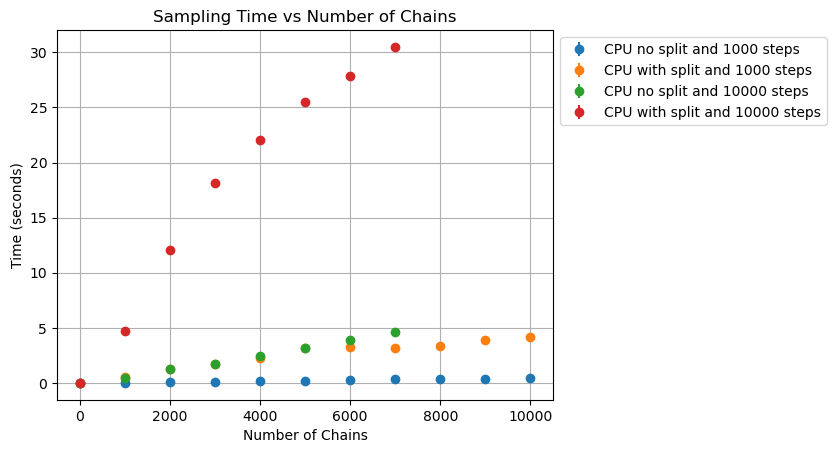

In [11]:
def extract_info_from_filename(filename):
    match = re.search(r"times_with_(\d+)_split_(True|False)", filename)
    if match:
        n_chains = int(match.group(1))
        split = match.group(2) == "True"
        return n_chains, split
    return None

def read_files(device):
    files = os.listdir(f"./results/{device}")
    times_split = {}
    for i,file in enumerate(files):
        times_split[i] = {"data": [], "metadata": {}}
        with open(f"./results/{device}/{file}", mode="r", newline="") as f:
            print(f"Reading file: {f.name}")
            reader = csv.reader(f)
            for row in reader:
                if row[0] != "Number of Chains":  # Skip header
                    times_split[i]["data"].append((int(row[0]), float(row[1]), float(row[2])))
                info = extract_info_from_filename(file)
                if info:
                    n_chains, split = info
                    times_split[i]["metadata"] = {"n_steps": n_chains, "split": split}
    return times_split

# times_cuda = read_files("cuda")
times_cpu = read_files("cpu")

def plot_from_times_dict(times_dict, label_prefix):
    for key, value in times_dict.items():
        label = f"{label_prefix} {'with' if value['metadata']['split'] else 'no'} split and {value['metadata']['n_steps']} steps"
        plt.errorbar(
            [x[0] for x in value['data']],
            [x[1] for x in value['data']],
            yerr=[x[2] for x in value['data']],
            fmt='o',
            label=label
        )

# plot_from_times_dict(times_cuda, 'CUDA')
plot_from_times_dict(times_cpu, 'CPU')


plt.xlabel('Number of Chains')
plt.ylabel('Time (seconds)')
plt.title('Sampling Time vs Number of Chains')
plt.legend(
    loc='upper left',           # the corner of the legend box
    bbox_to_anchor=(1, 1),      # position of the legend outside the plot (x=1, y=1)
    borderaxespad=0.5           # optional padding
)
# plt.semilogy()
plt.grid(True)